In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import linregress

In [3]:
BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR = BASE_DIR / "reports"

nav_df = pd.read_csv(
    PROCESSED_DIR / "clean_nav_history.csv"
)

benchmark_df = pd.read_csv(
    PROCESSED_DIR / "clean_benchmark.csv"
)

fund_df = pd.read_csv(
    PROCESSED_DIR / "clean_fund_master.csv"
)

perf_df = pd.read_csv(
    PROCESSED_DIR / "clean_performance.csv"
)

In [4]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

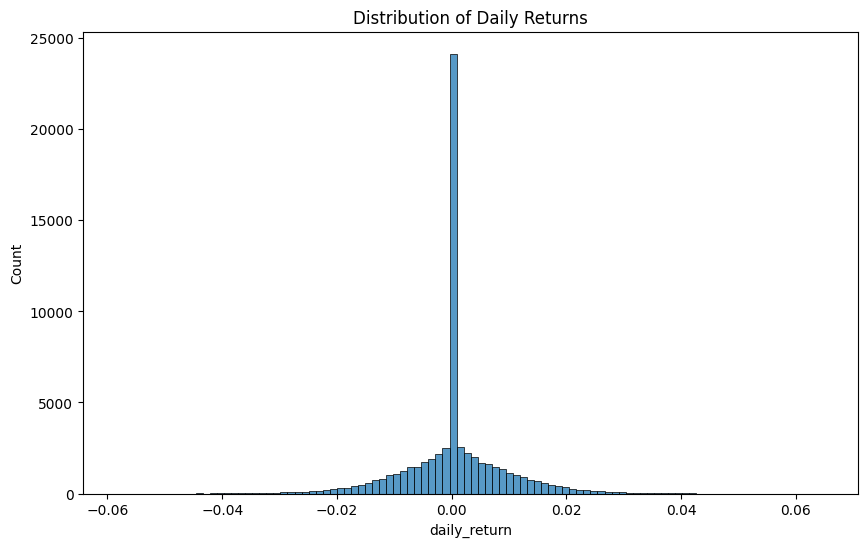

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

In [6]:
cagr_results = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    n_days = len(group)

    cagr = (
        (end_nav/start_nav)
        ** (252/n_days)
        - 1
    )

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

In [11]:
RF = 0.065

sharpe_results = []

for code, group in nav_df.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - RF/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

In [12]:
sortino_results = []

for code, group in nav_df.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    downside = returns[
        returns < 0
    ]

    downside_std = downside.std()

    sortino = (
        (returns.mean() - RF/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [13]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df.sort_values(
    "date"
)

benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
)

alpha_beta = []

for code, group in nav_df.groupby("amfi_code"):

    merged = pd.merge(
        group[
            ["date","daily_return"]
        ],
        benchmark_df[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    slope, intercept, r, p, stderr = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    alpha_beta.append(
        [
            code,
            intercept * 252,
            slope
        ]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    REPORT_DIR /
    "alpha_beta.csv",
    index=False
)

In [14]:
drawdowns = []

for code, group in nav_df.groupby("amfi_code"):

    running_max = (
        group["nav"]
        .cummax()
    )

    dd = (
        group["nav"]
        /
        running_max
        - 1
    )

    drawdowns.append(
        [
            code,
            dd.min()
        ]
    )

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [15]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
    .merge(
        fund_df[
            [
                "amfi_code",
                "expense_ratio_pct"
            ]
        ],
        on="amfi_code"
    )
)

In [16]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [17]:
scorecard["fund_score"] = (
    scorecard["return_rank"]*30
    +
    scorecard["sharpe_rank"]*25
    +
    scorecard["alpha_rank"]*20
    +
    scorecard["expense_rank"]*15
    +
    scorecard["dd_rank"]*10
)

scorecard.to_csv(
    REPORT_DIR /
    "fund_scorecard.csv",
    index=False
)

In [18]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)



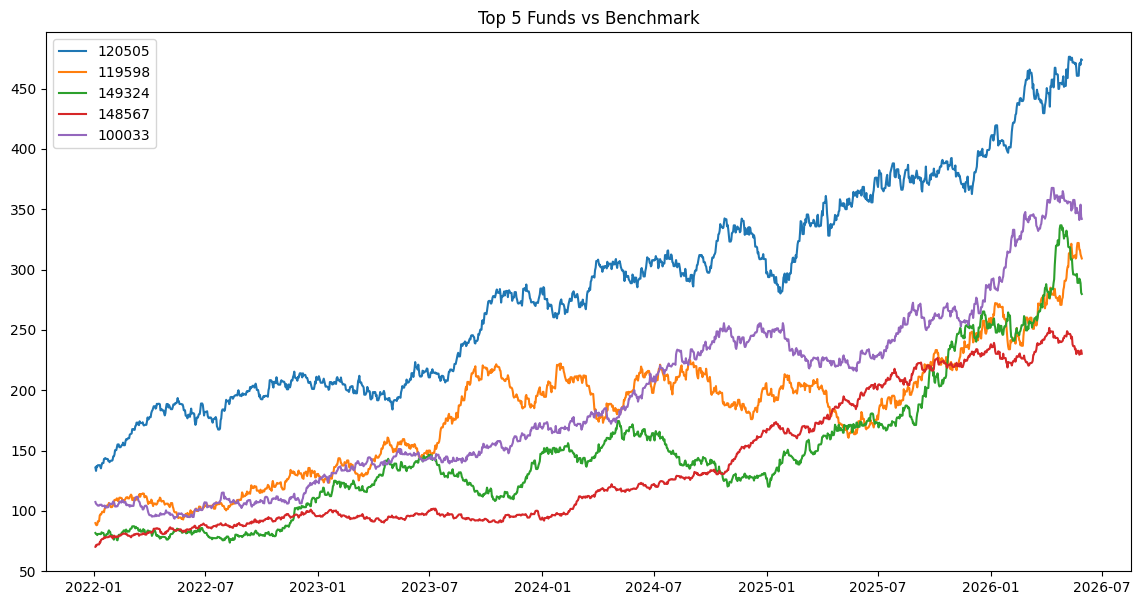

In [19]:
plt.figure(figsize=(14,7))

for code in top5["amfi_code"]:

    temp = nav_df[
        nav_df["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    REPORT_DIR /
    "benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()